# Analyzing Anime Trends in 2018 and Viewer Behaviors
##  Name: Kylie Higashionna

# Load in Imports

In [1]:
import pandas as pd
import zipfile
import os
from google.colab import drive
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, linregress
from scipy import stats
import numpy as np

# Load in the Data

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
zip_path = '/content/drive/MyDrive/anime_data/AnimeList.csv.zip'
extract_path = '/content'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files in /content:")
print(os.listdir('/content'))

Files in /content:
['.config', 'AnimeList.csv', 'drive', 'sample_data']


In [4]:
zip_path = '/content/drive/MyDrive/anime_data/UserList.csv.zip'
extract_path = '/content'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files in /content:")
print(os.listdir('/content'))

Files in /content:
['.config', 'AnimeList.csv', 'UserList.csv', 'drive', 'sample_data']


In [5]:
zip_path = '/content/drive/MyDrive/anime_data/UserAnimeList.csv.zip'
extract_path = '/content'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files in /content:")
print(os.listdir('/content'))

Files in /content:
['.config', 'AnimeList.csv', 'UserList.csv', 'drive', 'UserAnimeList.csv', 'sample_data']


In [6]:
zip_path = '/content/drive/MyDrive/anime_data/manga.csv.zip'
extract_path = '/content'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files in /content:")
print(os.listdir('/content'))

Files in /content:
['.config', 'AnimeList.csv', 'UserList.csv', 'drive', 'manga.csv', 'UserAnimeList.csv', 'sample_data']


In [7]:
zip_path = '/content/drive/MyDrive/anime_data/anime.csv.zip'
extract_path = '/content'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files in /content:")
print(os.listdir('/content'))

Files in /content:
['.config', 'AnimeList.csv', 'UserList.csv', 'drive', 'anime.csv', 'manga.csv', 'UserAnimeList.csv', 'sample_data']


# Explore the AnimeList Data

### Part 1: Get Top 50 TV Anime
Show the shape of AnimeList.csv and the first 3 rows

In [8]:
anime_list_df=pd.read_csv('AnimeList.csv')

In [9]:
print('Shape of df_anime', anime_list_df.shape)
anime_list_df.head(3)

Shape of df_anime (14478, 31)


,anime_id,title,title_english,title_japanese,title_synonyms,image_url,type,source,episodes,status,...,background,premiered,broadcast,related,producer,licensor,studio,genre,opening_theme,ending_theme
0,11013,Inu x Boku SS,Inu X Boku Secret Service,妖狐×僕SS,Youko x Boku SS,https://myanimelist.cdn-dena.com/images/anime/...,TV,Manga,12,Finished Airing,...,Inu x Boku SS was licensed by Sentai Filmworks...,Winter 2012,Fridays at Unknown,"{'Adaptation': [{'mal_id': 17207, 'type': 'man...","Aniplex, Square Enix, Mainichi Broadcasting Sy...",Sentai Filmworks,David Production,"Comedy, Supernatural, Romance, Shounen","['""Nirvana"" by MUCC']","['#1: ""Nirvana"" by MUCC (eps 1, 11-12)', '#2: ..."
1,2104,Seto no Hanayome,My Bride is a Mermaid,瀬戸の花嫁,The Inland Sea Bride,https://myanimelist.cdn-dena.com/images/anime/...,TV,Manga,26,Finished Airing,...,NaN,Spring 2007,Unknown,"{'Adaptation': [{'mal_id': 759, 'type': 'manga...","TV Tokyo, AIC, Square Enix, Sotsu",Funimation,Gonzo,"Comedy, Parody, Romance, School, Shounen","['""Romantic summer"" by SUN&LUNAR']","['#1: ""Ashita e no Hikari (明日への光)"" by Asuka Hi..."
2,5262,Shugo Chara!! Doki,Shugo Chara!! Doki,しゅごキャラ！！どきっ,"Shugo Chara Ninenme, Shugo Chara! Second Year",https://myanimelist.cdn-dena.com/images/anime/...,TV,Manga,51,Finished Airing,...,NaN,Fall 2008,Unknown,"{'Adaptation': [{'mal_id': 101, 'type': 'manga...","TV Tokyo, Sotsu",NaN,Satelight,"Comedy, Magic, School, Shoujo","['#1: ""Minna no Tamago (みんなのたまご)"" by Shugo Cha...","['#1: ""Rottara Rottara (ロッタラ ロッタラ)"" by Buono! ..."


Select only the anime that are of type "TV".
Filter to get only the top 50 TV anime based on the score.


In [10]:
tv_anime_df = anime_list_df[anime_list_df['type'] == 'TV']
top50_tv_anime = tv_anime_df.sort_values(by='score', ascending=False).head(50)


Only keep the 'title', 'score', and 'source' columns and re-index the dataframe to start from 1. Display resulting dataframe.

In [11]:
top50_tv_anime = top50_tv_anime[['title', 'score', 'source']].reset_index(drop=True)
top50_tv_anime.index = top50_tv_anime.index + 1
display(top50_tv_anime)

,title,score,source
1,Fullmetal Alchemist: Brotherhood,9.25,Manga
2,Steins;Gate 0,9.15,Visual novel
3,Gintama°,9.15,Manga
4,Steins;Gate,9.14,Visual novel
5,Hunter x Hunter (2011),9.11,Manga
6,Gintama&#039;,9.11,Manga
7,3-gatsu no Lion 2nd Season,9.10,Manga
8,Gintama&#039;: Enchousen,9.07,Manga
9,Owarimonogatari 2nd Season,9.02,Light novel
10,Gintama.,9.02,Manga


### Part 2: Get the Distribution of Source Material for the Top 50 TV Anime in 2018

Get the distribution of source material for the top 50 TV Anime in 2018 and display the table.

In [12]:
source_counts = top50_tv_anime['source'].value_counts()
display(source_counts)

,count
source,
Manga,34
Original,6
Visual novel,3
Light novel,2
Web manga,2
Novel,2
Other,1


Create a bar plot of the distribution of source material for top 50 TV Anime in 2018

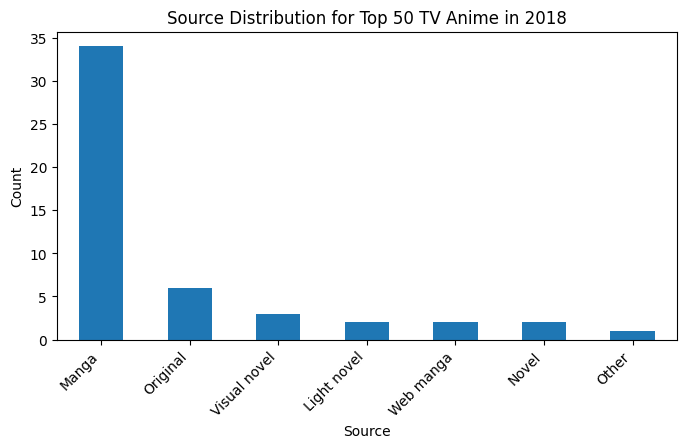

In [13]:
plt.figure(figsize=(8, 4))
source_counts.plot(kind='bar')
plt.title('Source Distribution for Top 50 TV Anime in 2018')
plt.xlabel('Source')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

# Correlation of score between Manga and its Anime counterpart



### Part 1: Explore the anime.csv

Display the shape and the first five rows.

In [14]:
anime_df=pd.read_csv('anime.csv')
print('Shape of anime_df', anime_df.shape)
anime_df.head(5)

Shape of anime_df (24985, 39)


,anime_id,title,type,score,scored_by,status,episodes,start_date,end_date,source,...,producers,licensors,synopsis,background,main_picture,url,trailer_url,title_english,title_japanese,title_synonyms
0,5114,Fullmetal Alchemist: Brotherhood,tv,9.10,2037075,finished_airing,64.0,2009-04-05,2010-07-04,manga,...,"['Aniplex', 'Square Enix', 'Mainichi Broadcast...","['Funimation', 'Aniplex of America']",After a horrific alchemy experiment goes wrong...,NaN,https://cdn.myanimelist.net/images/anime/1208/...,https://myanimelist.net/anime/5114/Fullmetal_A...,https://www.youtube.com/watch?v=--IcmZkvL0Q,Fullmetal Alchemist: Brotherhood,鋼の錬金術師 FULLMETAL ALCHEMIST,['Hagane no Renkinjutsushi: Fullmetal Alchemis...
1,11061,Hunter x Hunter (2011),tv,9.04,1671587,finished_airing,148.0,2011-10-02,2014-09-24,manga,...,"['VAP', 'Nippon Television Network', 'Shueisha']",['VIZ Media'],Hunters devote themselves to accomplishing haz...,NaN,https://cdn.myanimelist.net/images/anime/1337/...,https://myanimelist.net/anime/11061/Hunter_x_H...,https://www.youtube.com/watch?v=D9iTQRB4XRk,Hunter x Hunter,HUNTER×HUNTER（ハンター×ハンター）,['HxH (2011)']
2,38524,Shingeki no Kyojin Season 3 Part 2,tv,9.05,1491491,finished_airing,10.0,2019-04-29,2019-07-01,manga,...,"['Production I.G', 'Dentsu', 'Mainichi Broadca...",['Funimation'],Seeking to restore humanity's diminishing hope...,Shingeki no Kyojin adapts content from volumes...,https://cdn.myanimelist.net/images/anime/1517/...,https://myanimelist.net/anime/38524/Shingeki_n...,https://www.youtube.com/watch?v=hKHepjfj5Tw,Attack on Titan Season 3 Part 2,進撃の巨人 Season3 Part.2,[]
3,9253,Steins;Gate,tv,9.07,1348232,finished_airing,24.0,2011-04-06,2011-09-14,visual_novel,...,"['Frontier Works', 'Media Factory', 'Kadokawa ...",['Funimation'],Eccentric scientist Rintarou Okabe has a never...,Steins;Gate is based on 5pb. and Nitroplus' vi...,https://cdn.myanimelist.net/images/anime/1935/...,https://myanimelist.net/anime/9253/Steins_Gate,https://www.youtube.com/watch?v=27OZc-ku6is,Steins;Gate,STEINS;GATE,[]
4,28851,Koe no Katachi,movie,8.94,1540277,finished_airing,1.0,2016-09-17,2016-09-17,manga,...,"['Shochiku', 'Pony Canyon', 'Kodansha', 'ABC A...","['Eleven Arts', 'NYAV Post']","As a wild youth, elementary school student Sho...",Koe no Katachi won the following awards: Japan...,https://cdn.myanimelist.net/images/anime/1122/...,https://myanimelist.net/anime/28851/Koe_no_Kat...,https://www.youtube.com/watch?v=XBNWo25izJ8,A Silent Voice,聲の形,['The Shape of Voice']


Check the unique values in the 'type' and 'source' column of anime_df

In [15]:
anime_df['type'].unique()

array(['tv', 'movie', 'ona', 'ova', 'special', 'music', nan], dtype=object)

In [16]:
anime_df['source'].unique()

array(['manga', 'visual_novel', 'original', 'web_manga', 'light_novel',
       'novel', 'game', '4_koma_manga', 'music', 'other', 'web_novel',
       'card_game', 'book', 'mixed_media', nan, 'picture_book', 'radio'],
      dtype=object)

Drop any anime entries that have a missing (NaN) score

In [17]:
anime_df = anime_df.dropna(subset=['score'])

### Part 2: Explore the manga.csv

Display the shape and the first five rows.

In [18]:
manga_df=pd.read_csv('manga.csv')
print('Shape of manga_df', manga_df.shape)
manga_df.head(5)

Shape of manga_df (64833, 30)


,manga_id,title,type,score,scored_by,status,volumes,chapters,start_date,end_date,...,demographics,authors,serializations,synopsis,background,main_picture,url,title_english,title_japanese,title_synonyms
0,2,Berserk,manga,9.47,319696,currently_publishing,NaN,NaN,1989-08-25,NaN,...,['Seinen'],"[{'id': 1868, 'first_name': 'Kentarou', 'last_...",['Young Animal'],"Guts, a former mercenary now known as the ""Bla...",Berserk won the Award for Excellence at the si...,https://cdn.myanimelist.net/images/manga/1/157...,https://myanimelist.net/manga/2/Berserk,Berserk,ベルセルク,['Berserk: The Prototype']
1,13,One Piece,manga,9.22,355375,currently_publishing,NaN,NaN,1997-07-22,NaN,...,['Shounen'],"[{'id': 1881, 'first_name': 'Eiichiro', 'last_...",['Shounen Jump (Weekly)'],"Gol D. Roger, a man referred to as the ""King o...",One Piece is the highest selling manga series ...,https://cdn.myanimelist.net/images/manga/2/253...,https://myanimelist.net/manga/13/One_Piece,One Piece,ONE PIECE,[]
2,1706,JoJo no Kimyou na Bouken Part 7: Steel Ball Run,manga,9.30,151433,finished,24.0,96.0,2004-01-19,2011-04-19,...,"['Seinen', 'Shounen']","[{'id': 2619, 'first_name': 'Hirohiko', 'last_...",['Ultra Jump'],"In the American Old West, the world's greatest...",JoJo no Kimyou na Bouken Part 7: Steel Ball Ru...,https://cdn.myanimelist.net/images/manga/3/179...,https://myanimelist.net/manga/1706/JoJo_no_Kim...,NaN,ジョジョの奇妙な冒険 Part7 STEEL BALL RUN,"[""JoJo's Bizarre Adventure Part 7: Steel Ball ..."
3,4632,Oyasumi Punpun,manga,9.02,168459,finished,13.0,147.0,2007-03-15,2013-11-02,...,['Seinen'],"[{'id': 2836, 'first_name': 'Inio', 'last_name...",['Big Comic Spirits'],Punpun Onodera is a normal 11-year-old boy liv...,Oyasumi Punpun was originally serialized in Yo...,https://cdn.myanimelist.net/images/manga/3/266...,https://myanimelist.net/manga/4632/Oyasumi_Punpun,Goodnight Punpun,おやすみプンプン,[]
4,25,Fullmetal Alchemist,manga,9.03,153151,finished,27.0,116.0,2001-07-12,2010-09-11,...,['Shounen'],"[{'id': 1874, 'first_name': 'Hiromu', 'last_na...",['Shounen Gangan'],Alchemists are knowledgeable and naturally tal...,Hagane no Renkinjutsushi won the 49th Shogakuk...,https://cdn.myanimelist.net/images/manga/3/243...,https://myanimelist.net/manga/25/Fullmetal_Alc...,Fullmetal Alchemist,鋼の錬金術師,"['Full Metal Alchemist', 'Hagane no Renkinjuts..."


Check the unique values in the 'type' column of manga_df

In [19]:
manga_df['type'].unique()

array(['manga', 'manhwa', 'light_novel', 'one_shot', 'manhua', 'novel',
       'doujinshi'], dtype=object)

Drop any manga entries that have a missing (NaN) score

In [20]:
manga_df = manga_df.dropna(subset=['score'])

### Part 3: Clean and Merge the anime_df and manga_df


Select the anime with its type as tv, and its source material as manga. Select the manga with its type as manga

In [21]:
anime_tv = anime_df[(anime_df['type'] == 'tv') & (anime_df['source']== 'manga')]
manga_only = manga_df[manga_df['type'] == 'manga']

Create clean versions of the anime and manga dataframe by selecting only the title and score columns, then renaming the score columns for clarity. Display length the first five rows of each dataframe

In [22]:
anime_clean = anime_tv[['title', 'score']].rename(columns={'score': 'anime_score'})
manga_clean = manga_only[['title', 'score']].rename(columns={'score': 'manga_score'})

In [23]:
print("Length of anime_clean:", len(anime_clean))
anime_clean.head(5)

Length of anime_clean: 1547


,title,anime_score
0,Fullmetal Alchemist: Brotherhood,9.10
1,Hunter x Hunter (2011),9.04
2,Shingeki no Kyojin Season 3 Part 2,9.05
7,Shingeki no Kyojin: The Final Season,8.80
10,Death Note,8.62


In [24]:
print("Length of manga_clean:", len(manga_clean))
manga_clean.head(5)

Length of manga_clean: 19209


,title,manga_score
0,Berserk,9.47
1,One Piece,9.22
2,JoJo no Kimyou na Bouken Part 7: Steel Ball Run,9.30
3,Oyasumi Punpun,9.02
4,Fullmetal Alchemist,9.03


Merge the anime_clean and manga_clean dataframe on the title column using an inner join, then count the number of matching rows and display the first 5 rows.

In [25]:
merged_df = anime_clean.merge(manga_clean, on='title', how='inner')
print("Number of matching rows:", len(merged_df))
merged_df.head(5)

Number of matching rows: 779


,title,anime_score,manga_score
0,Death Note,8.62,8.70
1,One Piece,8.70,9.22
2,Jujutsu Kaisen,8.63,8.53
3,Shigatsu wa Kimi no Uso,8.65,8.59
4,Shingeki no Kyojin,8.54,8.55


### Part 4: Regression

Perform a linear regression analysis using manga_score as the independent variable (x) and anime_score as the dependent variable (y), then display the regression results

In [26]:
linreg = linregress(merged_df['manga_score'], merged_df['anime_score'])
print("Slope", linreg.slope)
print("Intercept", linreg.intercept)
print("Rvalue", linreg.rvalue)
print("Pvalue", linreg.pvalue)
print("Stderr", linreg.stderr)
print("Intercept_stderr", linreg.intercept_stderr)


Slope 0.8724074860008728
Intercept 0.6300699023740712
Rvalue 0.7632248614466768
Pvalue 1.5619064843401028e-149
Stderr 0.026495874955587667
Intercept_stderr 0.20164976870215712


Create a scatter plot comparing manga scores to anime adaptation scores and show the linear regression trend line

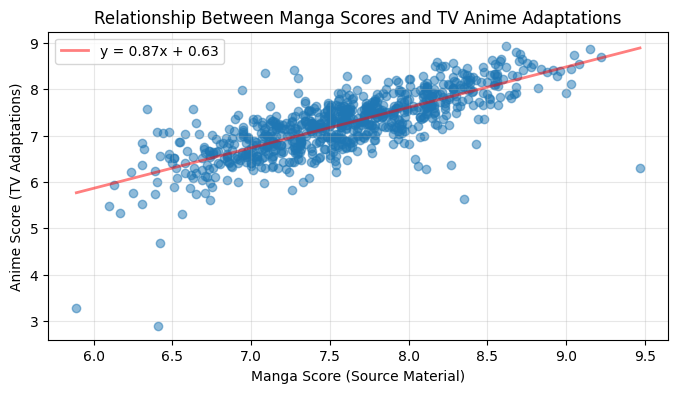

In [27]:
plt.figure(figsize=(8, 4))
x_axis = np.arange(min(merged_df['manga_score']), max(merged_df['manga_score']), 0.01)
y_axis = linreg.slope * x_axis + linreg.intercept
plt.plot(x_axis, y_axis, color='red', linewidth=2, label=f'y = {linreg.slope:.2f}x + {linreg.intercept:.2f}', alpha=0.5)
plt.scatter(merged_df['manga_score'], merged_df['anime_score'], alpha=0.5)

plt.xlabel("Manga Score (Source Material)")
plt.ylabel("Anime Score (TV Adaptations)")
plt.title("Relationship Between Manga Scores and TV Anime Adaptations")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Use bootstrap resampling to calculate the linear regression, storing the intercepts and slopes from each sample

In [28]:
bootstrap_intercepts = []
bootstrap_slopes = []

for i in range(50_000):
  sample_indexes = np.random.choice(merged_df.index, size=len(merged_df.index), replace=True)
  bootstrap_sample = merged_df.iloc[sample_indexes]
  linreg = linregress(bootstrap_sample['manga_score'], bootstrap_sample['anime_score'])
  bootstrap_intercepts.append(linreg.intercept)
  bootstrap_slopes.append(linreg.slope)

print("10 first intercepts:")
print(bootstrap_intercepts[:10])
print("10 first slopes:")
print(bootstrap_slopes[:10])

10 first intercepts:
[np.float64(0.4064009347088948), np.float64(0.12086464594839175), np.float64(0.698244697603398), np.float64(0.724984461230143), np.float64(1.0152153647740736), np.float64(0.146558179149185), np.float64(0.5067320823538504), np.float64(0.7127615833971523), np.float64(0.6073214095963131), np.float64(1.133023084553221)]
10 first slopes:
[np.float64(0.9017961597692653), np.float64(0.9383656357566753), np.float64(0.86432175986378), np.float64(0.8581639379612741), np.float64(0.8185176262160214), np.float64(0.9338713223650105), np.float64(0.8851754402158956), np.float64(0.8609245797365214), np.float64(0.8765628682168672), np.float64(0.8065842360006509)]


Create a scatter plot of manga scores versus anime scores and display the  bootstrap regression lines to visualize uncertainty in the relationship

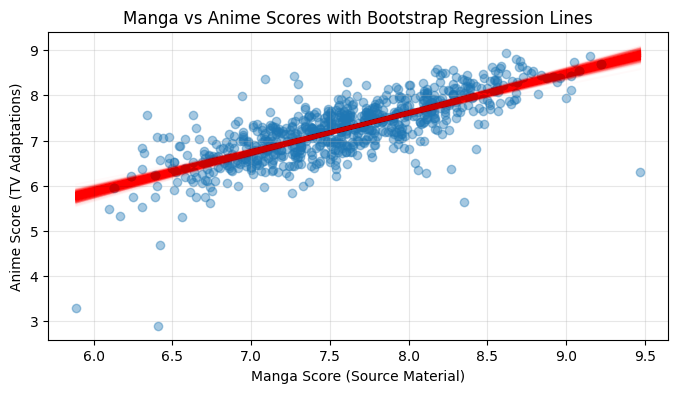

In [29]:
plt.figure(figsize=(8, 4))
plt.scatter(merged_df['manga_score'], merged_df['anime_score'], alpha=0.4)

x_axis = np.arange(min(merged_df['manga_score']), max(merged_df['manga_score']), 0.01)

for i in np.random.choice(range(50_000), 1000, replace=False):
  y_hat = bootstrap_slopes[i] * x_axis + bootstrap_intercepts[i]
  plt.plot(x_axis, y_hat, color='red', alpha=0.02)

plt.title("Manga vs Anime Scores with Bootstrap Regression Lines")
plt.xlabel("Manga Score (Source Material)")
plt.ylabel("Anime Score (TV Adaptations)")
plt.grid(alpha=0.3)
plt.show()

Create a histogram of the bootstrap slope estimates, compute the 95% confidence interval, and visualize the interval on the distribution

Slope Confidence Interval: [0.79744344 0.94743725]


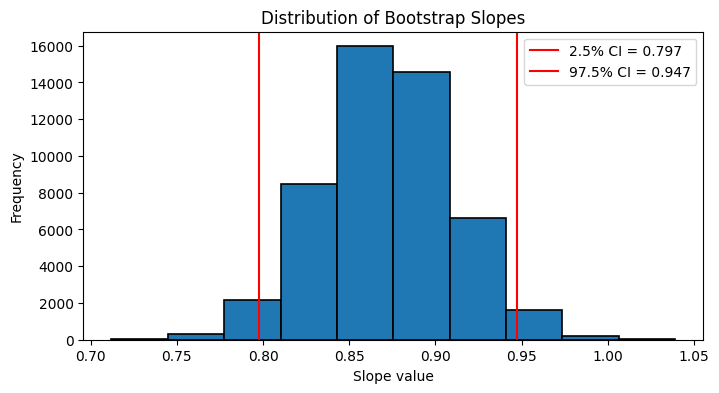

In [30]:
plt.figure(figsize=(8, 4))
plt.hist(bootstrap_slopes, edgecolor='black', linewidth=1.2)
plt.title("Distribution of Bootstrap Slopes")
plt.xlabel("Slope value")
plt.ylabel("Frequency")

conf_interval = np.percentile(bootstrap_slopes, [2.5, 97.5])
print("Slope Confidence Interval:", conf_interval)
plt.axvline(conf_interval[0], color='red', label=f'2.5% CI = {conf_interval[0]:.3f}')
plt.axvline(conf_interval[1], color='red',label=f'97.5% CI = {conf_interval[1]:.3f}')

plt.legend()
plt.show()

### Part 5: Correlation

Calculate the Pearson correlation coefficient and p-value between anime scores and manga scores

In [31]:
obs_corr, p_value = pearsonr(merged_df['anime_score'], merged_df['manga_score'])
print("Observed Correlation:", obs_corr)
print("p-value:", p_value)

Observed Correlation: 0.7632248614466762
p-value: 1.5619064843409973e-149


Calculate the Pearson correlation with bootstrapping

In [32]:
boot_corrs = []
for _ in range(10_000):
    sample_idx = np.random.choice(merged_df.index, size=len(merged_df), replace=True)
    bootstrap_sample = merged_df.iloc[sample_idx]
    boot_corr, _ = pearsonr(bootstrap_sample['anime_score'], bootstrap_sample['manga_score'])
    boot_corrs.append(boot_corr)

boot_corrs = np.array(boot_corrs)

Calculate the 95% bootstrap confidence interval for the correlation coefficient and print it alongside the observed correlation and p-value

In [33]:
# 95% confidence interval
conf_interval = np.percentile(boot_corrs, [2.5, 97.5])

print("Observed correlation:", obs_corr)
print("p-value:", p_value)
print(f"95% Bootstrap CI: [{conf_interval[0]}, {conf_interval[1]}]")

Observed correlation: 0.7632248614466762
p-value: 1.5619064843409973e-149
95% Bootstrap CI: [0.7186520948106493, 0.803416705000682]


Plot the bootstrap distribution of correlation values between manga and anime scores, and visualize the 95% confidence interval along with the observed correlation

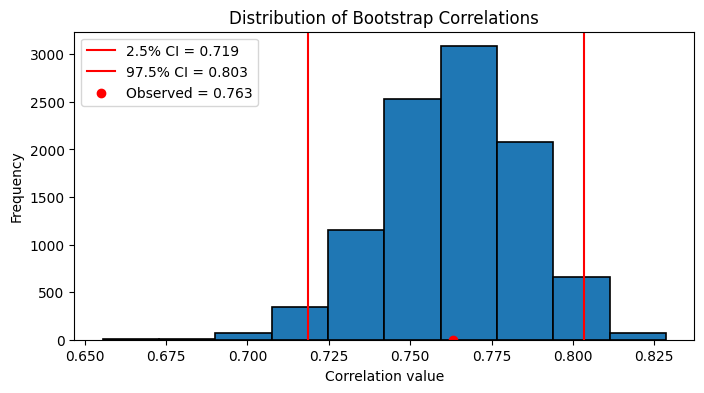

In [34]:
plt.figure(figsize=(8, 4))
plt.hist(boot_corrs, edgecolor='black', linewidth=1.2)
plt.title("Distribution of Bootstrap Correlations")
plt.xlabel("Correlation value")
plt.ylabel("Frequency")

plt.axvline(conf_interval[0], color='red', label=f'2.5% CI = {conf_interval[0]:.3f}')
plt.axvline(conf_interval[1], color='red', label=f'97.5% CI = {conf_interval[1]:.3f}')
plt.scatter(obs_corr, 0, color='red', label=f'Observed = {obs_corr:.3f}')

plt.legend()
plt.show()

Calculate proportion of variance in anime scores explained by manga scores

In [35]:
r_squared = obs_corr**2
print("R^2, proportion of variance in anime scores explained by manga scores:", r_squared)

R^2, proportion of variance in anime scores explained by manga scores: 0.5825121891302981


# Gender Comparison:


1. Do male and female users differ in their proportion of shounen anime in their viewing history?

  - H₀ (null): Male and female users have the same mean shounen_ratio

  - H₁ (alternative): Male and female users differ in their mean shounen_ratio
________________________________________________________________________________

2. Do male and female users differ in their proportion of shoujo anime in their viewing history?

  - H₀ (null): Male and female users have the same mean shoujo_ratio

  - H₁ (alternative): Male and female users differ in their mean shoujo_ratio

### Part 1: Clean the anime_df, user_list_df, and the user_anime_list_df


Only get the 'anime_id', 'title', and 'demographics' column from anime_df and drop any rows that have missing values. Create two new columns, one called 'is_Shounen' and another called 'is_shoujo', where they indicate whether each anime is classified as Shounen based on the demographics or Shoujo.

In [36]:
clean_anime_df = anime_df[['anime_id', 'title', 'demographics']].dropna()
clean_anime_df['is_shounen'] = clean_anime_df['demographics'].apply(lambda x: 'Shounen' in x).astype(int)
clean_anime_df['is_shoujo'] = clean_anime_df['demographics'].apply(lambda x: 'Shoujo' in x).astype(int)

Display the shape of clean_anime_df and the first three rows

In [37]:
print("Shape of clean_anime_df:", clean_anime_df.shape)
clean_anime_df.head(3)

Shape of clean_anime_df: (16050, 5)


,anime_id,title,demographics,is_shounen,is_shoujo
0,5114,Fullmetal Alchemist: Brotherhood,['Shounen'],1,0
1,11061,Hunter x Hunter (2011),['Shounen'],1,0
2,38524,Shingeki no Kyojin Season 3 Part 2,['Shounen'],1,0


Display the number of Shounen vs non-Shounen anime and Shoujo vs non-Shoujo anime

In [38]:
display(clean_anime_df['is_shounen'].value_counts())
display(clean_anime_df['is_shoujo'].value_counts())

,count
is_shounen,
0,14304
1,1746


,count
is_shoujo,
0,15439
1,611


Load the UserList dataset, filter for users whose gender is listed as Male or Female, keep only the 'username' and 'gender' columns, remove rows with missing usernames, and display the shape of the cleaned dataframe and the first three rows

In [39]:
user_list_df=pd.read_csv('UserList.csv')
user_clean = user_list_df[user_list_df['gender'].isin(['Male', 'Female'])][['username', 'gender']].dropna(subset=['username'])
print("Shape of user_clean:", user_clean.shape)
user_clean.head(3)

Shape of user_clean: (216554, 2)


,username,gender
0,karthiga,Female
1,RedvelvetDaisuki,Female
2,Damonashu,Male


Load the UserAnimeList dataset, filter records to include only users where the username exists in the user_clean dataframe, select only the 'username' and 'anime_id' columns, and display the shape of the cleaned dataframe and the first three rows

In [40]:
user_anime_list_df=pd.read_csv('UserAnimeList.csv')
user_anime_clean = user_anime_list_df[user_anime_list_df['username'].isin(user_clean['username'])][['username', 'anime_id']]
print("Shape of user_anime_clean:", user_anime_clean.shape)
user_anime_clean.head(3)

Shape of user_anime_clean: (64033696, 2)


,username,anime_id
0,karthiga,21
1,karthiga,59
2,karthiga,74


### Part 2: Merge datasets

Merge the user_anime_clean dataframe with the clean_anime_df dataframe on 'anime_id'.

Replace missing values (NaN) in the is_shounen and is_shoujo columns with 0.

Compute each user’s average proportion of Shounen and Shoujo anime they have watched, rename the resulting columns for clarity, and display the shape of the resulting DataFrame along with the first three rows.

In [41]:
merged_user_anime_df = user_anime_clean.merge(clean_anime_df[['anime_id', 'is_shounen', 'is_shoujo']], on='anime_id', how='left')

merged_user_anime_df[['is_shounen', 'is_shoujo']] = (merged_user_anime_df[['is_shounen', 'is_shoujo']].fillna(0))

user_genre_ratio = merged_user_anime_df.groupby('username')[['is_shounen', 'is_shoujo']].mean().reset_index()
user_genre_ratio = user_genre_ratio.rename(columns={'is_shounen': 'shounen_ratio','is_shoujo': 'shoujo_ratio'})
print("Shape of user_genre_ratio:", user_genre_ratio.shape)
user_genre_ratio.head(3)

Shape of user_genre_ratio: (210464, 3)


,username,shounen_ratio,shoujo_ratio
0,----------,0.241379,0.172414
1,-----aaa,0.207547,0.009434
2,----XII----,0.245487,0.083032


Merge the user_genre_ratio dataframe with the user_clean dataframe on username. Display the shape and first 3 rows of the merged dataset.

Compute the average Shounen and Shoujo viewing ratios for each gender and display its shape and the resulting summary table.

In [42]:
final_merge = user_genre_ratio.merge(user_clean[['username', 'gender']], on='username', how='left')
print("Shape of final_merge:", final_merge.shape)
display(final_merge.head(3))

gender_stats = final_merge.groupby('gender')[['shounen_ratio', 'shoujo_ratio']].mean()
print("Shape of gender_stats:", gender_stats.shape)
display(gender_stats)

Shape of final_merge: (210464, 4)


,username,shounen_ratio,shoujo_ratio,gender
0,----------,0.241379,0.172414,Male
1,-----aaa,0.207547,0.009434,Male
2,----XII----,0.245487,0.083032,Male


Shape of gender_stats: (2, 2)


,shounen_ratio,shoujo_ratio
gender,,
Female,0.250042,0.141059
Male,0.262023,0.032193


Extract the average Shounen and Shoujo viewing ratios for male and female users from the grouped results

In [43]:
shounen_female = gender_stats.loc['Female', 'shounen_ratio']
shounen_male = gender_stats.loc['Male', 'shounen_ratio']

shoujo_female = gender_stats.loc['Female', 'shoujo_ratio']
shoujo_male = gender_stats.loc['Male', 'shoujo_ratio']

### Part 3: Hypothesis Testing

Compute observed difference:


Observed difference in shounen_ratio: shounen_male - shounen_female


Observed difference in shoujo_ratio: shoujo_female - shoujo_male

In [44]:
obs_diff_shounen = shounen_male - shounen_female
print("Observed Difference in Mean Shounen Ratio:", obs_diff_shounen)

obs_diff_shoujo =shoujo_female - shoujo_male
print("Observed Difference in Mean Shoujo Ratio:", obs_diff_shoujo)

Observed Difference in Mean Shounen Ratio: 0.011980810055909286
Observed Difference in Mean Shoujo Ratio: 0.10886595903400689


Use permutation testing to simulate null distributions for gender differences in Shounen and Shoujo viewing ratios

In [45]:
perm_shounen_diffs = []
perm_shoujo_diffs = []

for _ in range(10_000):
    perm_df = final_merge.copy()
    perm_df['gender'] = np.random.permutation(perm_df['gender'].values)

    male = perm_df[perm_df['gender'] == 'Male']
    female = perm_df[perm_df['gender'] == 'Female']

    shounen_diff = male['shounen_ratio'].mean() - female['shounen_ratio'].mean()
    shoujo_diff = female['shoujo_ratio'].mean() - male['shoujo_ratio'].mean()

    perm_shounen_diffs.append(shounen_diff)
    perm_shoujo_diffs.append(shoujo_diff)

#### Shounen Hypothesis Test

##### Do male and female users differ in their proportion of shounen anime in their viewing history?

- H₀ (null): Male and female users have the same mean shounen_ratio

- H₁ (alternative): Male and female users differ in their mean shounen_ratio

Visualize the permutation null distribution for Shounen ratio differences and mark the observed value

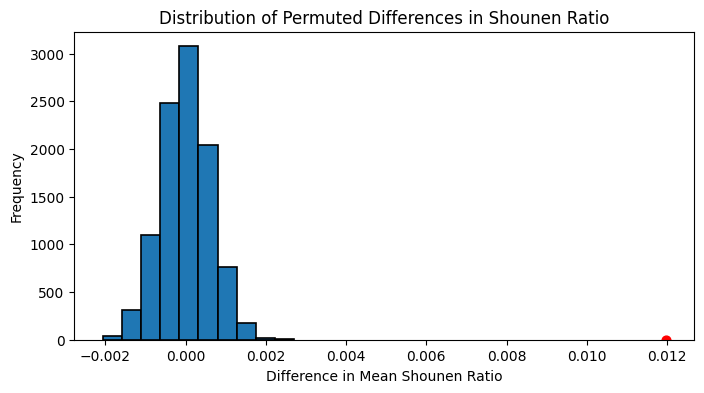

In [46]:
plt.figure(figsize=(8, 4))
plt.hist(perm_shounen_diffs, edgecolor='black', linewidth=1.2, bins=10)
plt.scatter(obs_diff_shounen, 0, color='r', s=40)

plt.title("Distribution of Permuted Differences in Shounen Ratio")
plt.xlabel("Difference in Mean Shounen Ratio")
plt.ylabel("Frequency")

plt.show()

Calculate the permutation test p-value by measuring the proportion of simulated Shounen ratio differences that are at least as extreme as the observed gender difference

In [47]:
p_value = np.mean(np.abs(perm_shounen_diffs) >= np.abs(obs_diff_shounen))
print("p-value:", p_value)

p-value: 0.0


#### Shoujo Hypothesis Test

##### Do male and female users differ in their proportion of shoujo anime in their viewing history?
- H₀ (null): Male and female users have the same mean shoujo_ratio

- H₁ (alternative): Male and female users differ in their mean shoujo_ratio

Visualize the permutation null distribution for Shoujo ratio differences and mark the observed value

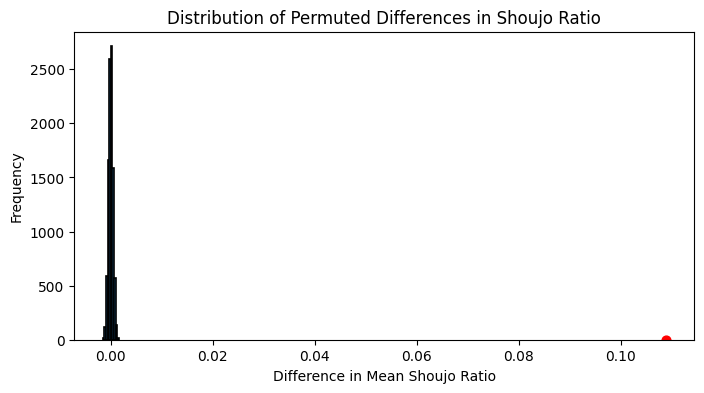

In [48]:
plt.figure(figsize=(8, 4))
plt.hist(perm_shoujo_diffs, edgecolor='black', linewidth=1.2, bins=10)
plt.scatter(obs_diff_shoujo, 0, color='r', s=40)

plt.title("Distribution of Permuted Differences in Shoujo Ratio")
plt.xlabel("Difference in Mean Shoujo Ratio")
plt.ylabel("Frequency")

plt.show()

Calculate the permutation test p-value by measuring the proportion of simulated Shoujo ratio differences that are at least as extreme as the observed gender difference

In [49]:
p_value = np.mean(np.abs(perm_shoujo_diffs) >= np.abs(obs_diff_shoujo))
print("p-value:", p_value)

p-value: 0.0


### Part 4: Welch's t-test

#### Shounen Welch's test

Compare the average Shounen viewing ratios of male and female users using Welch’s t-test

In [50]:
male_shounen = final_merge[final_merge['gender'] == 'Male']['shounen_ratio']
female_shounen = final_merge[final_merge['gender'] == 'Female']['shounen_ratio']

res = stats.ttest_ind(male_shounen, female_shounen, equal_var=False)

print("t-statistic:", round(res.statistic, 4))
print("p-value:", round(res.pvalue, 4))
print("df:", round(res.df, 1))

t-statistic: 19.3664
p-value: 0.0
df: 158517.2


#### Shoujo Welch's test

Compare the average Shoujo viewing ratios of male and female users using Welch’s t-test

In [51]:
male_shoujo = final_merge[final_merge['gender'] == 'Male']['shoujo_ratio']
female_shoujo = final_merge[final_merge['gender'] == 'Female']['shoujo_ratio']

res = stats.ttest_ind(female_shoujo, male_shoujo, equal_var=False)

print("t-statistic:", round(res.statistic.item(), 4))
print("p-value:", round(res.pvalue.item(), 4))
print("df:", round(res.df.item(), 1))

t-statistic: 229.3479
p-value: 0.0
df: 86277.3


### Part 5: Cohen's d

Cohen’s d is a standardized effect size that measures the magnitude of the difference between two group means by expressing that difference in standard deviation units.

d = 0.2, small difference

d = 0.5, medium difference

d = 0.8, large difference

#### Shounen Ratio Cohen's d

Compute Cohen’s d effect size for the gender difference in Shounen preference

In [52]:
# Compute sample size
n_male = len(male_shounen)
n_female = len(female_shounen)

# Compute mean
mean_male = male_shounen.mean()
mean_female = female_shounen.mean()

# Compute sample standard deviation
std_male = male_shounen.std(ddof=1)
std_female = female_shounen.std(ddof=1)

# Calculate the pooled standard deviation using both groups’ variances
numerator = ((n_male - 1) * (std_male**2)) + ((n_female - 1) * (std_female**2))
denominator = n_male + n_female - 2
pooled_std = np.sqrt(numerator / denominator)

# Computes Cohen’s d
cohens_d_shounen = (mean_male - mean_female) / pooled_std
print("Cohen’s d for Shounen Ratio:", cohens_d_shounen)

Cohen’s d for Shounen Ratio: 0.08832465957833542


#### Shoujo Ratio Cohen's d

Compute Cohen’s d effect size for the gender difference in Shoujo preference

In [53]:
# Compute sample size
n_male = len(male_shoujo)
n_female = len(female_shoujo)

# Compute mean
mean_male = male_shoujo.mean()
mean_female = female_shoujo.mean()

# Compute sample standard deviation
std_male = male_shoujo.std(ddof=1)
std_female = female_shoujo.std(ddof=1)

# Calculate the pooled standard deviation using both groups’ variances
numerator = ((n_male - 1) * (std_male**2)) + ((n_female - 1) * (std_female**2))
denominator = n_male + n_female - 2
pooled_std = np.sqrt(numerator / denominator)

# Computes Cohen’s d
cohens_d_shoujo = (mean_female - mean_male) / pooled_std
print("Cohen’s d for Shoujo Ratio:", cohens_d_shoujo)

Cohen’s d for Shoujo Ratio: 1.2883575006399164
